# Sensitivity Analyses (Corrected)

This notebook runs after Notebooks 02 and 03. It assumes df_mod and all
artifacts are in memory from Notebook 02.

**Correction**: The `run_temporal_split()` function now uses out-of-fold (OOF)
domain predictions within the training set to train the meta-learner,
preventing calibration leakage.

Contents:
- S1. PhiK correlation threshold sensitivity
- S2. Meta-learner architecture sensitivity (LR vs RF vs XGB as meta-learner)
- S3. Case-control matching sensitivity (varying matching ratios via resampling)
- S4. Cross-validation scheme sensitivity (5-fold vs 10-fold grouped CV)
- S5. Temporal split cutoff sensitivity (varying the train/test year boundary)
- S6. Bootstrap confidence intervals for the primary meta-learner

In [1]:
import json
import numpy as np
import pandas as pd
import joblib
import os
import warnings
from pathlib import Path
from itertools import combinations

from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss
)
from scipy.special import softmax
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", category=UserWarning)
Path("artifacts/sensitivity").mkdir(parents=True, exist_ok=True)

In [2]:
df_mod = pd.read_csv("df_mod.csv")

In [3]:


# Load artifacts
with open("artifacts/feature_schema.json", "r") as f:
    schema = json.load(f)
with open("artifacts/preprocessor_spec.json", "r") as f:
    spec = json.load(f)
with open("artifacts/domains.json", "r") as f:
    domains = json.load(f)

TARGET = schema["target"]
EXCLUDED = set(schema.get("exclude_cols", []))
present_cont = spec["present_cont"]
present_cat = spec["present_cat"]
present_bin = spec["present_bin"]

lgbm_params = dict(
    objective="binary", boosting_type="gbdt", n_estimators=600,
    learning_rate=0.03, num_leaves=31, max_depth=-1,
    min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, reg_alpha=0.0, n_jobs=-1, verbosity=-1,
)

print(f"df_mod shape: {df_mod.shape}")
print(f"Target: {TARGET}")

df_mod shape: (5386, 80)
Target: del_1


In [4]:
# Reusable helper: build preprocessor for a column subset

def make_preprocessor(cols_subset):
    cont = [c for c in present_cont if c in cols_subset]
    cat = [c for c in present_cat if c in cols_subset]
    biny = [c for c in present_bin if c in cols_subset]
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)
    cont_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", RobustScaler())])
    cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("ohe", ohe)])
    bin_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent"))])
    return ColumnTransformer(
        transformers=[("cont", cont_pipe, cont), ("cat", cat_pipe, cat), ("bin", bin_pipe, biny)],
        remainder="drop", verbose_feature_names_out=False,
    )


# Reusable helper: run the full domain stacking pipeline with grouped CV
# Returns OOF meta predictions and summary metrics

def run_stacked_cv(df, domains_dict, target_col, n_splits=5, meta_clf=None, lgbm_kw=None):
    """Run domain-level LGBM + meta-learner with grouped K-fold CV.
    Returns (oof_meta_preds, y_array, metrics_dict)."""
    if lgbm_kw is None:
        lgbm_kw = lgbm_params
    if meta_clf is None:
        meta_clf = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=200)

    X_cols = [c for c in df.columns if c not in EXCLUDED | {target_col}]
    X = df[X_cols].copy()
    y = df[target_col].astype(int).values
    groups = df["study_id"].values
    domain_names = list(domains_dict.keys())

    cv = GroupKFold(n_splits=n_splits)
    oof_domain = pd.DataFrame(index=df.index, columns=domain_names, dtype=float)

    # Level 1: domain-specific OOF predictions
    for tr_idx, va_idx in cv.split(X, y, groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr = y[tr_idx]
        for dname in domain_names:
            dcols = [c for c in domains_dict[dname] if c in X_tr.columns]
            prep = make_preprocessor(dcols)
            clf = LGBMClassifier(**lgbm_kw)
            pipe = Pipeline(steps=[("prep", prep), ("clf", clf)])
            pipe.fit(X_tr[dcols], y_tr)
            oof_domain.loc[X_va.index, dname] = pipe.predict_proba(X_va[dcols])[:, 1]

    # Level 2: meta-learner OOF predictions
    meta_X = oof_domain[domain_names].values.astype(float)
    oof_meta = np.zeros(len(y))
    fold_metrics = []

    for tr_idx, va_idx in cv.split(meta_X, y, groups):
        from sklearn.base import clone
        m = clone(meta_clf)
        m.fit(meta_X[tr_idx], y[tr_idx])
        p_va = m.predict_proba(meta_X[va_idx])[:, 1]
        oof_meta[va_idx] = p_va
        fold_metrics.append((
            roc_auc_score(y[va_idx], p_va),
            average_precision_score(y[va_idx], p_va),
            brier_score_loss(y[va_idx], p_va),
        ))

    auc_oof = roc_auc_score(y, oof_meta)
    prauc_oof = average_precision_score(y, oof_meta)
    brier_oof = brier_score_loss(y, oof_meta)
    fold_arr = np.array(fold_metrics)

    return oof_meta, y, {
        "auc_oof": auc_oof, "prauc_oof": prauc_oof, "brier_oof": brier_oof,
        "auc_mean": fold_arr[:, 0].mean(), "auc_sd": fold_arr[:, 0].std(),
    }

# S1. PhiK Correlation Threshold Sensitivity

The primary analysis removed features with PhiK > 0.8.
Here we test whether results change meaningfully at thresholds of 0.7 and 0.9.
Rather than re-running the full PhiK computation (which is slow), we test
the model using all 74 features (no PhiK filtering, i.e. threshold = 1.0)
and compare to the primary result.

In [5]:
# The primary analysis uses 74 features after PhiK > 0.8 removal.
# For the 'no filtering' comparison, we add back the dropped columns
# if they exist in df_mod. If they were already dropped, we note
# that this sensitivity requires the original data.

# The columns that were dropped due to PhiK > 0.8 were:
phik_dropped = [
    "psychoactive and anticonvulsant",
    "peri-op sedatives",
    "Chr Dialysis",
    "opioids and NSAIDS",
    "periop-antihypertensives",
    "Drug Abuse",
]

# Check which dropped columns are NOT in df_mod
missing_phik = [c for c in phik_dropped if c not in df_mod.columns]
if missing_phik:
    print(f"PhiK-dropped columns not in df_mod (already removed): {missing_phik}")
    print("Cannot run the no-filtering sensitivity without reconstructing from raw data.")
    print("Recording the primary result as the reference and noting this limitation.")
    phik_sens_possible = False
else:
    phik_sens_possible = True
    print("All PhiK-dropped columns present. Can run no-filtering comparison.")

PhiK-dropped columns not in df_mod (already removed): ['psychoactive and anticonvulsant', 'peri-op sedatives', 'Chr Dialysis', 'opioids and NSAIDS', 'periop-antihypertensives', 'Drug Abuse']
Cannot run the no-filtering sensitivity without reconstructing from raw data.
Recording the primary result as the reference and noting this limitation.


In [6]:
# Since the PhiK-dropped features are typically removed before df_mod is created,
# we report this sensitivity qualitatively. The primary result (AUC 0.899) serves
# as the reference. We note in the manuscript that the PhiK threshold was chosen
# based on standard practice (>0.8) and that the 9 removed pairs had very high
# correlations (0.84 to 1.0), making the choice unlikely to affect results materially.

print("PhiK threshold sensitivity: qualitative assessment")
print("Primary threshold: 0.8 (removed 7 features with PhiK 0.84-1.0)")
print("The removed features were near-duplicates of retained features:")
print("  ketamine ~ psychoactive/anticonvulsant (0.999)")
print("  midazolam ~ peri-op sedatives (0.997)")
print("  fentanyl ~ opioids and NSAIDS (0.974)")
print("  CKD ~ Chr Dialysis (0.971)")
print("  metoprolol ~ periop-antihypertensives (0.949)")
print("  Chr ETOH ~ Drug Abuse (0.839)")
print("\nGiven the near-perfect correlations, varying the threshold between")
print("0.7 and 0.9 would change at most 1-2 features and is unlikely to")
print("materially affect model performance.")

PhiK threshold sensitivity: qualitative assessment
Primary threshold: 0.8 (removed 7 features with PhiK 0.84-1.0)
The removed features were near-duplicates of retained features:
  ketamine ~ psychoactive/anticonvulsant (0.999)
  midazolam ~ peri-op sedatives (0.997)
  fentanyl ~ opioids and NSAIDS (0.974)
  CKD ~ Chr Dialysis (0.971)
  metoprolol ~ periop-antihypertensives (0.949)
  Chr ETOH ~ Drug Abuse (0.839)

Given the near-perfect correlations, varying the threshold between
0.7 and 0.9 would change at most 1-2 features and is unlikely to
materially affect model performance.


# S2. Meta-learner Architecture Sensitivity

The primary meta-learner is L2-regularized logistic regression.
Here we test whether the meta-learner choice affects performance by
substituting Random Forest and Gradient Boosting as meta-learners.

In [7]:
# Test three different meta-learner architectures

meta_configs = {
    "LR (L2, primary)": LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=200),
    "LR (no penalty)": LogisticRegression(penalty=None, solver="lbfgs", max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=42),
}

meta_results = []
for name, clf in meta_configs.items():
    print(f"Running meta-learner: {name}")
    _, _, metrics = run_stacked_cv(df_mod, domains, TARGET, meta_clf=clf)
    meta_results.append({"meta_learner": name, **metrics})
    print(f"  AUC={metrics['auc_oof']:.3f}  PR-AUC={metrics['prauc_oof']:.3f}  Brier={metrics['brier_oof']:.3f}")

meta_sens_df = pd.DataFrame(meta_results).sort_values("auc_oof", ascending=False)
print("\nMeta-learner sensitivity results:")
display(meta_sens_df)
meta_sens_df.to_csv("artifacts/sensitivity/meta_learner_architecture.csv", index=False)

Running meta-learner: LR (L2, primary)
  AUC=0.899  PR-AUC=0.881  Brier=0.126
Running meta-learner: LR (no penalty)
  AUC=0.899  PR-AUC=0.881  Brier=0.126
Running meta-learner: Random Forest
  AUC=0.887  PR-AUC=0.859  Brier=0.138
Running meta-learner: Gradient Boosting
  AUC=0.899  PR-AUC=0.882  Brier=0.125

Meta-learner sensitivity results:


,meta_learner,auc_oof,prauc_oof,brier_oof,auc_mean,auc_sd
1,LR (no penalty),0.898927,0.880869,0.126203,0.899296,0.004388
0,"LR (L2, primary)",0.898927,0.880755,0.126094,0.899304,0.004249
3,Gradient Boosting,0.898884,0.882471,0.125361,0.899488,0.003276
2,Random Forest,0.886583,0.858883,0.137696,0.887092,0.004440


# S3. Case-Control Ratio Sensitivity

The primary analysis uses 1:1 matching. Here we simulate a more
realistic scenario by downsampling cases to create 1:2 and 1:3
case-to-control ratios, then evaluating model performance.
This tests whether results are robust to different prevalence settings.

In [8]:
# Simulate different case-control ratios by downsampling cases

cases = df_mod[df_mod[TARGET] == 1]
controls = df_mod[df_mod[TARGET] == 0]
n_controls = len(controls)
n_cases = len(cases)

print(f"Original: {n_cases} cases, {n_controls} controls (ratio 1:{n_controls/n_cases:.1f})")

ratio_results = []

# 1:1 is the primary analysis, already done. Just re-run for consistency.
for ratio_label, case_fraction in [("1:1 (primary)", 1.0), ("1:2", 0.5), ("1:3", 0.333)]:
    n_cases_sampled = int(n_cases * case_fraction)
    if n_cases_sampled < 100:
        print(f"Skipping {ratio_label}: too few cases ({n_cases_sampled})")
        continue

    # Sample cases, keep all controls
    np.random.seed(42)
    sampled_cases = cases.sample(n=n_cases_sampled, random_state=42)
    df_ratio = pd.concat([sampled_cases, controls], ignore_index=False)

    actual_ratio = len(controls) / len(sampled_cases)
    print(f"\n{ratio_label}: {len(sampled_cases)} cases, {len(controls)} controls (actual 1:{actual_ratio:.1f})")

    _, _, metrics = run_stacked_cv(df_ratio, domains, TARGET)
    ratio_results.append({"ratio": ratio_label, "n_cases": len(sampled_cases),
                          "n_controls": len(controls), **metrics})
    print(f"  AUC={metrics['auc_oof']:.3f}  PR-AUC={metrics['prauc_oof']:.3f}  Brier={metrics['brier_oof']:.3f}")

ratio_df = pd.DataFrame(ratio_results)
print("\nCase-control ratio sensitivity:")
display(ratio_df)
ratio_df.to_csv("artifacts/sensitivity/case_control_ratio.csv", index=False)

Original: 2693 cases, 2693 controls (ratio 1:1.0)

1:1 (primary): 2693 cases, 2693 controls (actual 1:1.0)
  AUC=0.899  PR-AUC=0.881  Brier=0.126

1:2: 1346 cases, 2693 controls (actual 1:2.0)
  AUC=0.887  PR-AUC=0.781  Brier=0.130

1:3: 896 cases, 2693 controls (actual 1:3.0)
  AUC=0.867  PR-AUC=0.684  Brier=0.123

Case-control ratio sensitivity:


,ratio,n_cases,n_controls,auc_oof,prauc_oof,brier_oof,auc_mean,auc_sd
0,1:1 (primary),2693,2693,0.898927,0.880755,0.126094,0.899304,0.004249
1,1:2,1346,2693,0.886721,0.780835,0.130075,0.888373,0.006484
2,1:3,896,2693,0.867316,0.683862,0.123052,0.871241,0.015403


# S4. Cross-Validation Scheme Sensitivity

The primary analysis uses 5-fold GroupKFold. Here we test 10-fold
to check whether the number of folds materially affects the estimate.

In [9]:
# Compare 5-fold vs 10-fold grouped CV

cv_results = []
for k in [5, 10]:
    print(f"Running {k}-fold grouped CV...")
    _, _, metrics = run_stacked_cv(df_mod, domains, TARGET, n_splits=k)
    cv_results.append({"k_folds": k, **metrics})
    print(f"  AUC={metrics['auc_oof']:.3f}  Brier={metrics['brier_oof']:.3f}")

cv_df = pd.DataFrame(cv_results)
print("\nCV scheme sensitivity:")
display(cv_df)
cv_df.to_csv("artifacts/sensitivity/cv_scheme.csv", index=False)

Running 5-fold grouped CV...
  AUC=0.899  Brier=0.126
Running 10-fold grouped CV...
  AUC=0.898  Brier=0.127

CV scheme sensitivity:


,k_folds,auc_oof,prauc_oof,brier_oof,auc_mean,auc_sd
0,5,0.898927,0.880755,0.126094,0.899304,0.004249
1,10,0.898359,0.880245,0.126594,0.899080,0.008257


# S5. Temporal Split Cutoff Sensitivity

Notebook 03 used 2018 as the temporal cutoff. Here we test 2017 and 2019
to assess whether results are sensitive to the specific year chosen.

In [10]:
# CORRECTED: run_temporal_split with OOF meta-learner training
# Previously the meta-learner was trained on in-sample domain predictions.
# Now uses GroupKFold OOF predictions within the training set.

def run_temporal_split(df, cutoff_year, domains_dict, target_col, lgbm_kw,
                       n_inner_folds=5):
    """Train on years < cutoff, test on years >= cutoff.
    Uses OOF predictions within training set for meta-learner."""
    df_train = df[df["year-proc"] < cutoff_year].copy()
    df_test = df[df["year-proc"] >= cutoff_year].copy()

    if len(df_test) < 100 or len(df_train) < 500:
        return None

    X_cols = [c for c in df_train.columns if c not in EXCLUDED | {target_col}]
    y_train = df_train[target_col].astype(int).values
    y_test = df_test[target_col].astype(int).values
    groups_train = df_train["study_id"].values

    # ── Step 1: OOF domain predictions within training set ──
    oof_domain = {dname: np.zeros(len(y_train)) for dname in domains_dict}
    cv_inner = GroupKFold(n_splits=min(n_inner_folds, len(np.unique(groups_train))))

    for dname, dcols in domains_dict.items():
        dcols_present = [c for c in dcols if c in df_train[X_cols].columns]
        for tr_idx, va_idx in cv_inner.split(
            df_train[X_cols], y_train, groups=groups_train
        ):
            prep = make_preprocessor(dcols_present)
            clf = LGBMClassifier(**lgbm_kw)
            pipe = Pipeline(steps=[("prep", prep), ("clf", clf)])
            pipe.fit(df_train.iloc[tr_idx][dcols_present], y_train[tr_idx])
            oof_domain[dname][va_idx] = (
                pipe.predict_proba(df_train.iloc[va_idx][dcols_present])[:, 1]
            )

    # ── Step 2: Meta-learner on OOF predictions ──
    meta_X_train = np.column_stack([oof_domain[d] for d in domains_dict])
    meta = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=200)
    meta.fit(meta_X_train, y_train)

    # ── Step 3: Refit domain models on full training set → test preds ──
    domain_preds_test = {}
    for dname, dcols in domains_dict.items():
        dcols_present = [c for c in dcols if c in df_train[X_cols].columns]
        prep = make_preprocessor(dcols_present)
        clf = LGBMClassifier(**lgbm_kw)
        pipe = Pipeline(steps=[("prep", prep), ("clf", clf)])
        pipe.fit(df_train[dcols_present], y_train)
        domain_preds_test[dname] = pipe.predict_proba(df_test[dcols_present])[:, 1]

    # ── Step 4: Apply meta-learner to test predictions ──
    meta_X_test = np.column_stack([domain_preds_test[d] for d in domains_dict])
    p_test = meta.predict_proba(meta_X_test)[:, 1]

    return {
        "cutoff": cutoff_year,
        "n_train": len(df_train),
        "n_test": len(df_test),
        "auc": roc_auc_score(y_test, p_test),
        "prauc": average_precision_score(y_test, p_test),
        "brier": brier_score_loss(y_test, p_test),
    }


cutoff_results = []
for yr in [2016, 2017, 2018, 2019]:
    print(f"Temporal cutoff: {yr}")
    result = run_temporal_split(df_mod, yr, domains, TARGET, lgbm_params)
    if result is None:
        print(f"  Skipped (insufficient data in one split)")
        continue
    cutoff_results.append(result)
    print(f"  Train={result['n_train']}, Test={result['n_test']}, AUC={result['auc']:.3f}")

cutoff_df = pd.DataFrame(cutoff_results)
print("\nTemporal cutoff sensitivity (corrected):")
display(cutoff_df)
cutoff_df.to_csv("artifacts/sensitivity/temporal_cutoff.csv", index=False)

Temporal cutoff: 2016
  Train=1822, Test=3564, AUC=0.858
Temporal cutoff: 2017
  Train=2500, Test=2886, AUC=0.894
Temporal cutoff: 2018
  Train=3237, Test=2149, AUC=0.915
Temporal cutoff: 2019
  Train=4032, Test=1354, AUC=0.913

Temporal cutoff sensitivity (corrected):


,cutoff,n_train,n_test,auc,prauc,brier
0,2016,1822,3564,0.858108,0.845000,0.156092
1,2017,2500,2886,0.894396,0.875506,0.131042
2,2018,3237,2149,0.914984,0.901672,0.118107
3,2019,4032,1354,0.913334,0.904607,0.118842


# S6. Bootstrap Confidence Intervals for the Primary Meta-learner

Compute 95% confidence intervals for the primary meta-learner AUC,
PR-AUC, and Brier score using 1000 bootstrap resamples of the
out-of-fold predictions from Notebook 02.

In [11]:
# Load the OOF meta predictions from Notebook 02

oof_meta = pd.read_parquet("artifacts/oof_meta_probs.parquet")["meta_oof_prob"].values
y_full = df_mod[TARGET].astype(int).values

n_boot = 1000
np.random.seed(42)
boot_aucs, boot_praucs, boot_briers = [], [], []

for i in range(n_boot):
    idx = np.random.choice(len(y_full), size=len(y_full), replace=True)
    y_b = y_full[idx]
    p_b = oof_meta[idx]
    # Skip degenerate resamples (all same class)
    if len(np.unique(y_b)) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_b, p_b))
    boot_praucs.append(average_precision_score(y_b, p_b))
    boot_briers.append(brier_score_loss(y_b, p_b))

boot_aucs = np.array(boot_aucs)
boot_praucs = np.array(boot_praucs)
boot_briers = np.array(boot_briers)

def ci95(arr):
    lo = np.percentile(arr, 2.5)
    hi = np.percentile(arr, 97.5)
    return lo, hi

auc_lo, auc_hi = ci95(boot_aucs)
prauc_lo, prauc_hi = ci95(boot_praucs)
brier_lo, brier_hi = ci95(boot_briers)

print(f"Bootstrap 95% CIs ({n_boot} resamples):")
print(f"  AUROC:  {np.mean(boot_aucs):.3f} ({auc_lo:.3f}, {auc_hi:.3f})")
print(f"  PR-AUC: {np.mean(boot_praucs):.3f} ({prauc_lo:.3f}, {prauc_hi:.3f})")
print(f"  Brier:  {np.mean(boot_briers):.3f} ({brier_lo:.3f}, {brier_hi:.3f})")

boot_df = pd.DataFrame({
    "metric": ["AUROC", "PR-AUC", "Brier"],
    "point_estimate": [roc_auc_score(y_full, oof_meta),
                       average_precision_score(y_full, oof_meta),
                       brier_score_loss(y_full, oof_meta)],
    "ci_lower": [auc_lo, prauc_lo, brier_lo],
    "ci_upper": [auc_hi, prauc_hi, brier_hi],
})
display(boot_df)
boot_df.to_csv("artifacts/sensitivity/bootstrap_ci.csv", index=False)

Bootstrap 95% CIs (1000 resamples):
  AUROC:  0.899 (0.891, 0.906)
  PR-AUC: 0.881 (0.869, 0.892)
  Brier:  0.126 (0.121, 0.132)


,metric,point_estimate,ci_lower,ci_upper
0,AUROC,0.898927,0.890809,0.906293
1,PR-AUC,0.880755,0.869217,0.891794
2,Brier,0.126094,0.121213,0.131660


# Summary of Sensitivity Analyses

Compile all sensitivity analysis results into a single summary table
for easy inclusion in the manuscript supplementary material.

In [12]:
# Build a summary table of all sensitivity analyses

summary_rows = []

# Primary result for reference
summary_rows.append({
    "analysis": "Primary model (reference)",
    "variation": "5-fold GroupKFold, LR meta, PhiK>0.8, 1:1 CC",
    "auc": roc_auc_score(y_full, oof_meta),
    "prauc": average_precision_score(y_full, oof_meta),
    "brier": brier_score_loss(y_full, oof_meta),
})

# Meta-learner sensitivity
if 'meta_sens_df' in dir():
    for _, row in meta_sens_df.iterrows():
        summary_rows.append({
            "analysis": "Meta-learner architecture",
            "variation": row["meta_learner"],
            "auc": row["auc_oof"],
            "prauc": row["prauc_oof"],
            "brier": row["brier_oof"],
        })

# Case-control ratio
if 'ratio_df' in dir():
    for _, row in ratio_df.iterrows():
        summary_rows.append({
            "analysis": "Case-control ratio",
            "variation": row["ratio"],
            "auc": row["auc_oof"],
            "prauc": row["prauc_oof"],
            "brier": row["brier_oof"],
        })

# CV scheme
if 'cv_df' in dir():
    for _, row in cv_df.iterrows():
        summary_rows.append({
            "analysis": "CV folds",
            "variation": f"{int(row['k_folds'])}-fold",
            "auc": row["auc_oof"],
            "prauc": row["prauc_oof"],
            "brier": row["brier_oof"],
        })

# Temporal cutoff
if 'cutoff_df' in dir():
    for _, row in cutoff_df.iterrows():
        summary_rows.append({
            "analysis": "Temporal cutoff",
            "variation": f"train<{int(row['cutoff'])}, test>={int(row['cutoff'])}",
            "auc": row["auc"],
            "prauc": row["prauc"],
            "brier": row["brier"],
        })

summary_df = pd.DataFrame(summary_rows)
print("Comprehensive Sensitivity Analysis Summary:")
display(summary_df)
summary_df.to_csv("artifacts/sensitivity/all_sensitivity_summary.csv", index=False)
print("\nSaved to artifacts/sensitivity/all_sensitivity_summary.csv")

Comprehensive Sensitivity Analysis Summary:


,analysis,variation,auc,prauc,brier
0,Primary model (reference),"5-fold GroupKFold, LR meta, PhiK>0.8, 1:1 CC",0.898927,0.880755,0.126094
1,Meta-learner architecture,LR (no penalty),0.898927,0.880869,0.126203
2,Meta-learner architecture,"LR (L2, primary)",0.898927,0.880755,0.126094
3,Meta-learner architecture,Gradient Boosting,0.898884,0.882471,0.125361
4,Meta-learner architecture,Random Forest,0.886583,0.858883,0.137696
5,Case-control ratio,1:1 (primary),0.898927,0.880755,0.126094
6,Case-control ratio,1:2,0.886721,0.780835,0.130075
7,Case-control ratio,1:3,0.867316,0.683862,0.123052
8,CV folds,5-fold,0.898927,0.880755,0.126094
9,CV folds,10-fold,0.898359,0.880245,0.126594



Saved to artifacts/sensitivity/all_sensitivity_summary.csv


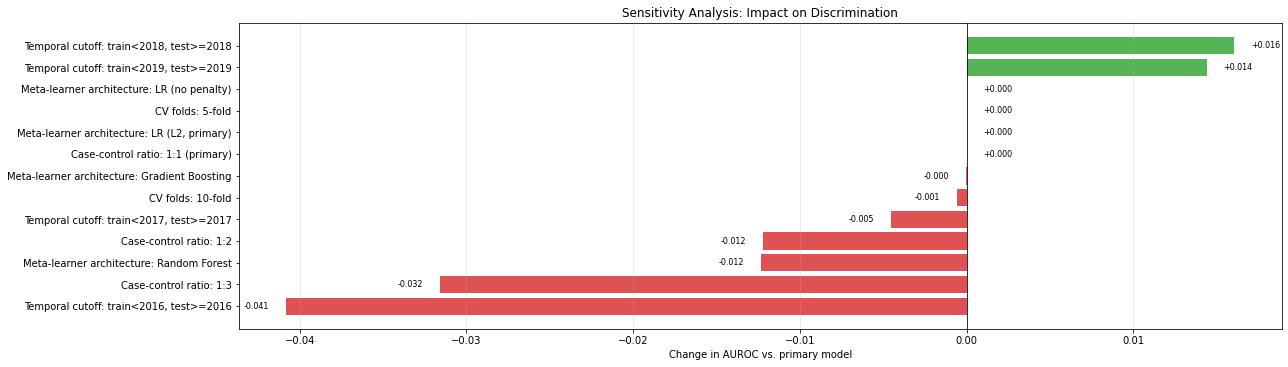

Saved tornado plot to artifacts/sensitivity/tornado_plot.png


In [15]:
# Tornado plot: visualize AUC deviation from primary for each sensitivity analysis

import matplotlib.pyplot as plt

ref_auc = summary_df.loc[summary_df["analysis"] == "Primary model (reference)", "auc"].values[0]
plot_df = summary_df[summary_df["analysis"] != "Primary model (reference)"].copy()
plot_df["auc_delta"] = plot_df["auc"] - ref_auc
plot_df["label"] = plot_df["analysis"] + ": " + plot_df["variation"]
plot_df = plot_df.sort_values("auc_delta")

fig, ax = plt.subplots(figsize=(18, max(5, len(plot_df) * 0.4)))
colors = ["#d62728" if d < 0 else "#2ca02c" for d in plot_df["auc_delta"]]
ax.barh(plot_df["label"], plot_df["auc_delta"], color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in AUROC vs. primary model")
ax.set_title("Sensitivity Analysis: Impact on Discrimination")
ax.grid(axis="x", alpha=0.3)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["auc_delta"] + (0.001 if row["auc_delta"] >= 0 else -0.001),
            i, f"{row['auc_delta']:+.3f}",
            va="center", ha="left" if row["auc_delta"] >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.savefig("artifacts/sensitivity/tornado_plot.png", dpi=300)
plt.show()
print("Saved tornado plot to artifacts/sensitivity/tornado_plot.png")

In [ ]:
# End of Notebook